# Introduction

This project analyzes a **Superstore Sales Dataset** from the **Sales and E-Commerce domain**.  
The dataset contains information related to customer orders, product categories, sales, profit, discounts, payment methods, and time-based data.

The main objective of this project is to analyze **sales trends**, **customer purchasing behavior**, and **profitability patterns** using data analytics techniques.

By performing **data preprocessing, and exploratory data analysis (EDA)**, this project aims to extract meaningful insights that can help in better business decision-making and performance evaluation.

## Attribute Information

The dataset contains the following important attributes:

- **Order_ID** – Unique identifier for each order  
- **Order_Date** – Date and time when the order was placed  
- **Customer_ID** – Unique customer identifier  
- **Country** – Country where the order was placed  
- **Category** – Product category  
- **Sub_Category** – Sub-category of the product  
- **Quantity** – Number of items ordered  
- **Unit_Price** – Price per unit  
- **Sales** – Total sales value  
- **Discount** – Discount applied on the order  
- **Profit** – Profit earned from the order  
- **Payment_Method** – Mode of payment 

## About the Dataset

- **Dataset Name:** Superstore Sales Dataset  
- **Domain:** Sales and E-Commerce  
- **Data Type:** CSV (Comma Separated Values)  
- **Number of Rows:** 5,000  
- **Number of Columns:** 13 

## Step 1: Importing Libraries
Imported the  Python libraries for data analysis and visualization.
- Pandas: For data handling
- NumPy: For numerical operations
- Matplotlib & Seaborn: For charts and visualizations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline

## Step 2: Loading the Dataset
- Loaded the Superstore Sales dataset into a DataFrame. 
- Displayed the first few rows to understand the structure of the dataset

In [4]:
df = pd.read_csv("Superstore_Sales_5000.csv")

In [5]:
df.head()

,Order_ID,Order_Date,Customer_ID,Country,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Payment_Method,Segment
0,1,2023-01-01 00:00:00,1684,Canada,Sports,Fitness,2,237.83,475.66,0.08,87.37,PayPal,Corporate
1,2,2023-01-01 01:00:00,1559,USA,Toys,Educational,5,229.61,1148.05,0.12,171.46,COD,Home Office
2,3,2023-01-01 02:00:00,1629,Germany,Electronics,Phones,8,57.28,458.24,0.02,50.21,Net Banking,Home Office
3,4,2023-01-01 03:00:00,1192,USA,Clothing,Kids,9,450.56,4055.04,0.04,793.50,Credit Card,Consumer
4,5,2023-01-01 04:00:00,1835,India,Sports,Fitness,2,7.27,14.54,0.15,2.27,Net Banking,Home Office


## Step 3: Converting Order Date to Datetime Format

The Order_Date column is initially read as text when loading the CSV file.
To perform time-based analysis such as extracting month, year, and weekday,
the Order_Date column is converted into datetime format.

In [37]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [38]:
df["Order_Date"].dtype

dtype('<M8[ns]')

## Step 4 : Dataset Overview
- Checked the number of rows and columns in the dataset.
- Viewed the data types of each column.
- Generated basic statistical summary to understand distributions and ranges

In [8]:
df.shape

(5000, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        5000 non-null   int64         
 1   Order_Date      5000 non-null   datetime64[ns]
 2   Customer_ID     5000 non-null   int64         
 3   Country         5000 non-null   object        
 4   Category        5000 non-null   object        
 5   Sub_Category    5000 non-null   object        
 6   Quantity        5000 non-null   int64         
 7   Unit_Price      5000 non-null   float64       
 8   Sales           5000 non-null   float64       
 9   Discount        5000 non-null   float64       
 10  Profit          5000 non-null   float64       
 11  Payment_Method  5000 non-null   object        
 12  Segment         5000 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(5)
memory usage: 507.9+ KB


In [10]:
df.describe()

,Order_ID,Order_Date,Customer_ID,Quantity,Unit_Price,Sales,Discount,Profit
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2023-04-15 03:30:00,1498.197200,4.950800,252.828704,1249.706290,0.150232,155.665060
min,1.000000,2023-01-01 00:00:00,1000.000000,1.000000,5.190000,5.400000,0.000000,0.290000
25%,1250.750000,2023-02-22 01:45:00,1245.750000,3.000000,127.172500,401.370000,0.080000,45.137500
50%,2500.500000,2023-04-15 03:30:00,1499.000000,5.000000,253.755000,961.385000,0.150000,110.355000
75%,3750.250000,2023-06-06 05:15:00,1753.000000,7.000000,376.752500,1858.020000,0.220000,222.560000
max,5000.000000,2023-07-28 07:00:00,1999.000000,9.000000,499.980000,4494.150000,0.300000,828.850000
std,1443.520003,NaN,290.059967,2.567118,143.756327,1034.845836,0.085928,146.186534


## Step 5: Duplicate Check¶
- Checked for duplicate rows in the dataset.
- No duplicate records were found

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(5000, 13)

## Step 6: Missing Values Check
- Used df.isnull().sum() to check for missing values in each column.
- The result shows that there are no missing values in the dataset.
- Therefore, the dataset is clean.

In [16]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Country           0
Category          0
Sub_Category      0
Quantity          0
Unit_Price        0
Sales             0
Discount          0
Profit            0
Payment_Method    0
Segment           0
dtype: int64

## Step 7: : Creating New Date Columns
- Created new time-based columns from the Order_Date column:
- Month Column: Helps analyze monthly sales trends.
- year Column: Useful for comparing performance across years.
- Weekday Column: Helps understand which days of the week have more orders.

In [42]:
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Weekday'] = df['Order_Date'].dt.day_name()

In [43]:
df.head()

,Order_ID,Order_Date,Customer_ID,Country,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Payment_Method,Segment,Month,Year,Weekday
0,1,2023-01-01 00:00:00,1684,Canada,Sports,Fitness,2,237.83,475.66,0.08,87.37,PayPal,Corporate,1,2023,Sunday
1,2,2023-01-01 01:00:00,1559,USA,Toys,Educational,5,229.61,1148.05,0.12,171.46,COD,Home Office,1,2023,Sunday
2,3,2023-01-01 02:00:00,1629,Germany,Electronics,Phones,8,57.28,458.24,0.02,50.21,Net Banking,Home Office,1,2023,Sunday
3,4,2023-01-01 03:00:00,1192,USA,Clothing,Kids,9,450.56,4055.04,0.04,793.50,Credit Card,Consumer,1,2023,Sunday
4,5,2023-01-01 04:00:00,1835,India,Sports,Fitness,2,7.27,14.54,0.15,2.27,Net Banking,Home Office,1,2023,Sunday


## Step 8: Added Profit Margin Column
- Created a new column called Profit_Margin to understand how much percentage profit is made from each sale.

In [24]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [22]:
df['Profit_Margin'].head()

0    18.368162
1    14.934890
2    10.957140
3    19.568241
4    15.612105
Name: Profit_Margin, dtype: float64

## Step 9: Checking Sales and Profit Distribution
- This step is used to understand the range of Sales and Profit values in the dataset.
- The minimum value shows the lowest sales and profit recorded.
- The maximum value shows the highest sales and profit recorded.

In [47]:
df[['Sales', 'Profit']].min(), df[['Sales', 'Profit']].max()

(Sales     5.40
 Profit    0.29
 dtype: float64,
 Sales     4494.15
 Profit     828.85
 dtype: float64)

## Step 10 : Checking Unique Categories

- This step checks how many different values are present in each category column.  
- It helps us understand how many countries, product categories, payment methods, and customer segments are in the dataset.


In [7]:
df[['Country','Category','Sub_Category','Payment_Method','Segment']].nunique()

Country            6
Category           6
Sub_Category      17
Payment_Method     5
Segment            3
dtype: int64

## Step 11: Checking for Zero or Negative Sales
- This step checks if any sales values are zero or negative, which could indicate data errors.

In [8]:
df[df['Sales'] <= 0]

,Order_ID,Order_Date,Customer_ID,Country,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Payment_Method,Segment


## Step 12: Sorting Orders by Date
- This step arranges all orders in the dataset based on the order date.
- It helps to view the data in proper time order and makes time-based analysis easier.

In [11]:
df = df.sort_values(by='Order_Date')

In [12]:
df.head()

,Order_ID,Order_Date,Customer_ID,Country,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Payment_Method,Segment
0,1,2023-01-01 00:00:00,1684,Canada,Sports,Fitness,2,237.83,475.66,0.08,87.37,PayPal,Corporate
1,2,2023-01-01 01:00:00,1559,USA,Toys,Educational,5,229.61,1148.05,0.12,171.46,COD,Home Office
2,3,2023-01-01 02:00:00,1629,Germany,Electronics,Phones,8,57.28,458.24,0.02,50.21,Net Banking,Home Office
3,4,2023-01-01 03:00:00,1192,USA,Clothing,Kids,9,450.56,4055.04,0.04,793.50,Credit Card,Consumer
4,5,2023-01-01 04:00:00,1835,India,Sports,Fitness,2,7.27,14.54,0.15,2.27,Net Banking,Home Office


## Step 13 : Final Dataset Ready for EDA
- Preprocessing Completed
- After performing data cleaning, validation, and feature creation, the dataset is now ready for exploratory data analysis (EDA) and visualization.

In [14]:
df.shape

(5000, 13)

# EDA — Exploratory Data Analysis

## EDA Step 1: Overall Sales and Profit Summary

- This step calculates the total sales and total profit
-  It helps us understand how much revenue and profit the business has generated overall.

In [6]:
df[['Sales', 'Profit']].sum()

Sales     6248531.45
Profit     778325.30
dtype: float64

## EDA Step 2: Average Order Value

- This step calculates the average sales amount per order.
- It shows how much revenue is generated on average from each order.

In [7]:
df['Sales'].mean()

np.float64(1249.7062899999999)

 ## EDA Step 3: Sales by Product Categor
- This step calculates total sales for each product category.
- It helps us understand which type of products generate the highest revenue.

In [8]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Home           1068493.62
Clothing       1063079.27
Electronics    1050190.52
Toys           1045246.89
Sports         1020120.45
Beauty         1001400.70
Name: Sales, dtype: float64

## EDA Step 4: Profit by Product Category

- This step calculates total profit for each category.
- It helps identify which product types are most profitable.

In [9]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Home           133885.03
Clothing       133031.31
Electronics    131484.85
Toys           129902.78
Beauty         125017.00
Sports         125004.33
Name: Profit, dtype: float64

## EDA Step 5: Sales by Country

- This step shows how sales are distributed across different countries.
- It helps identify top performing regions.

In [10]:
df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

Country
USA          1121266.59
Canada       1067682.67
India        1044098.71
Germany      1010993.26
UK           1008993.42
Australia     995496.80
Name: Sales, dtype: float64

## EDA Step 6: Payment Method Usage

- This step counts how many orders are made using each payment method.
- It helps understand customer payment preferences.

In [11]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card    1046
COD            1027
PayPal          986
Net Banking     984
UPI             957
Name: count, dtype: int64

## EDA Step 7: Monthly Sales Trend
## To understand how sales change over time and identify seasonal patterns.
- df.columns -  To understand how sales change over time and identify seasonal patterns
- Datetime format is required to extract month, year, and other time-based values.
- create the Month column so we can group sales month-wise.
- df.groupby('Month')['Sales'].sum() - This adds up all sales for each month to show how revenue changes over time.

In [15]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Country', 'Category',
       'Sub_Category', 'Quantity', 'Unit_Price', 'Sales', 'Discount', 'Profit',
       'Payment_Method', 'Segment'],
      dtype='object')

In [16]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [17]:
df['Month'] = df['Order_Date'].dt.month

In [18]:
df.groupby('Month')['Sales'].sum()

Month
1    907501.50
2    854779.60
3    895370.91
4    934815.88
5    913704.46
6    916993.44
7    825365.66
Name: Sales, dtype: float64

## EDA Step 8: Profit Margin Summary

- This step is for understand how much profit is earned from each sale.
- df['Profit_Margin' = (df['Profit' / df['Sales') * 100  This step helps to  Calculates profit percentage instead of raw profit.
- df['Profit_Margin'.describe() This step helps to Shows average, minimum, and maximum profit margin.
- This all steps Helps evaluate how profitable the business is overall.

In [20]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [21]:
df[['Profit', 'Sales', 'Profit_Margin']].head()

,Profit,Sales,Profit_Margin
0,87.37,475.66,18.368162
1,171.46,1148.05,14.934890
2,50.21,458.24,10.957140
3,793.50,4055.04,19.568241
4,2.27,14.54,15.612105


In [22]:
df['Profit_Margin'].describe()

count    5000.000000
mean       12.552224
std         4.302084
min         5.001909
25%         8.919660
50%        12.487080
75%        16.299466
max        19.995180
Name: Profit_Margin, dtype: float64

## EDA Step 9: Sales Distribution
## understand how sales values are spread across orders.
- plt.hist(df['Sales', bins=30) Shows whether most orders are small, medium, or large
- This histogram shows how sales values are distributed across all orders.

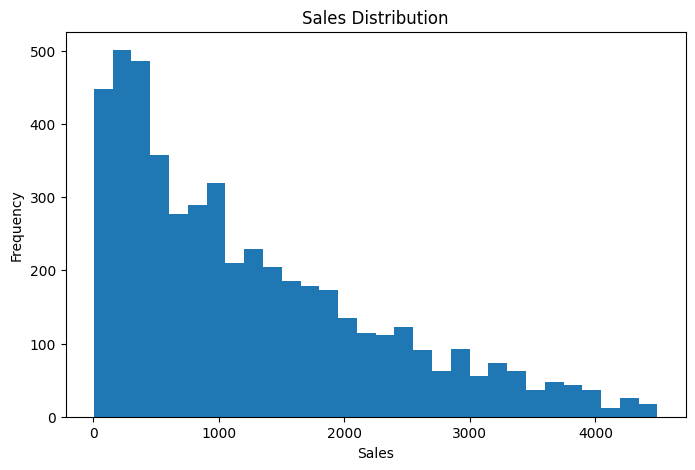

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## EDA Step 10: Relationship between Sales and Profit
## check how profit changes with sales
- plt.scatter(df['Sales', df['Profit') Shows if higher sales usually produce higher profit.
- This scatter plot shows how profit changes with sales amount.

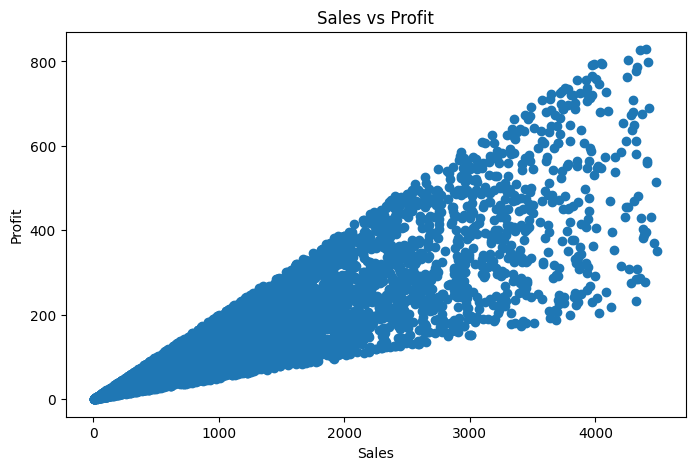

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

## EDA Step 11: Key Insights

- This section summarizes the major findings from exploratory data analysis.
- It includes sales trends, profitable categories, customer behavior, and time-based patterns.

## Visualization 

## Visualization 1: Sales by Product Category (Bar Chart)

- This bar chart shows total sales for each product category.
- It helps identify which categories generate the most revenue.

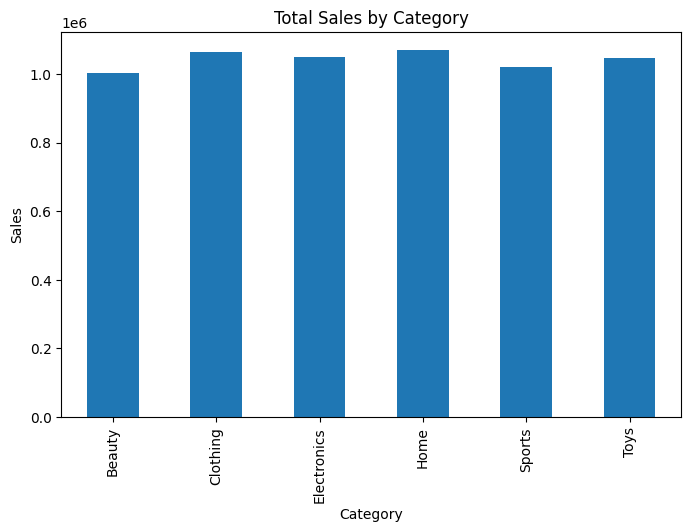

In [5]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

## Visualization 2: Profit by Product Category (Bar Chart)

- This chart shows how much profit each category generates.
- It helps identify the most profitable product types.

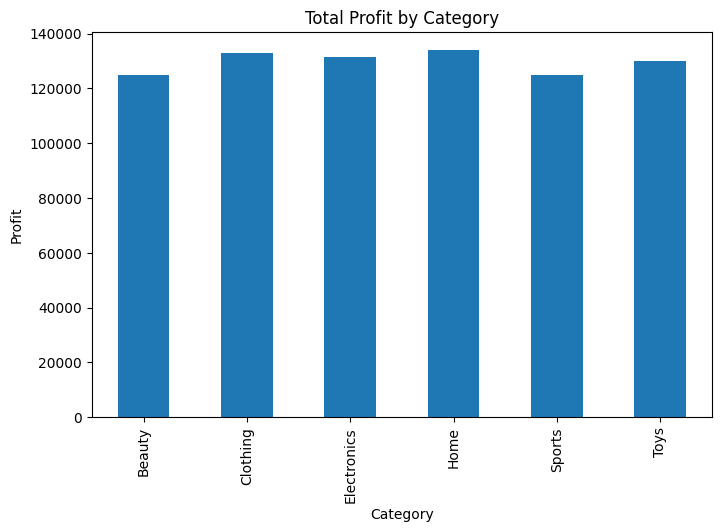

In [7]:
category_profit = df.groupby('Category')['Profit'].sum()
plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## Visualization 3: Sales by Country (Bar Chart)

- This bar chart compares total sales across different countries.
- It helps identify top-performing markets.

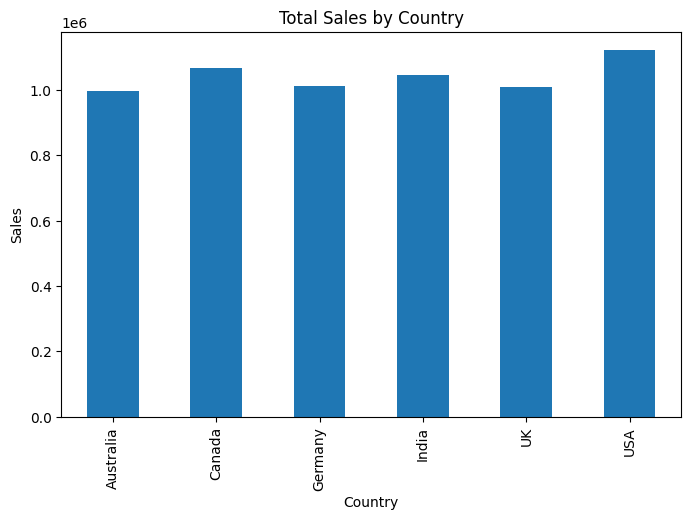

In [8]:
country_sales = df.groupby('Country')['Sales'].sum()
plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

## Visualization 4: Monthly Sales Trend (Line Chart)

- This line chart shows how sales change over time.
- It helps identify seasonality and trends.

In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [11]:
df['Month'] = df['Order_Date'].dt.month

In [12]:
df[['Order_Date','Month']].head()

,Order_Date,Month
0,2023-01-01 00:00:00,1
1,2023-01-01 01:00:00,1
2,2023-01-01 02:00:00,1
3,2023-01-01 03:00:00,1
4,2023-01-01 04:00:00,1


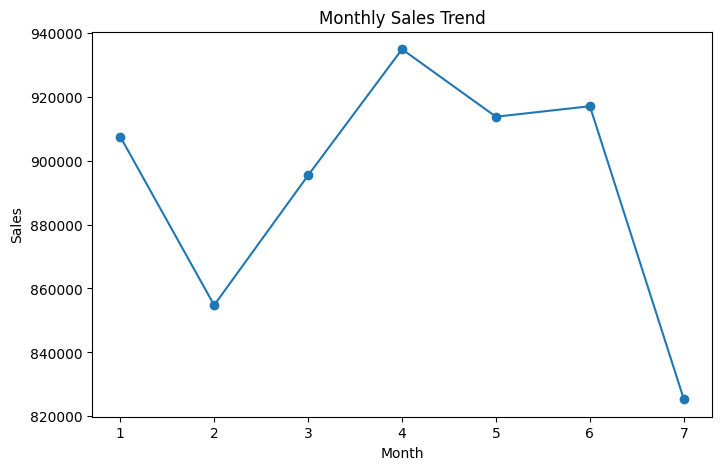

In [13]:
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Visalization 5: Sales Distribution (Histogram)

- This histogram shows how sales values are spread across orders.
- It helps identify common order sizes and outliers.

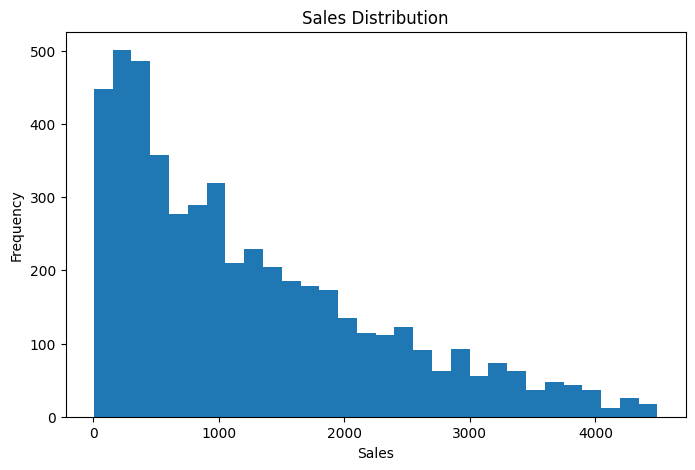

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## Visualization 6: Sales vs Profit (Scatter Plot)

- This scatter plot shows the relationship between sales and profit.
- It helps understand whether higher sales lead to higher profit.

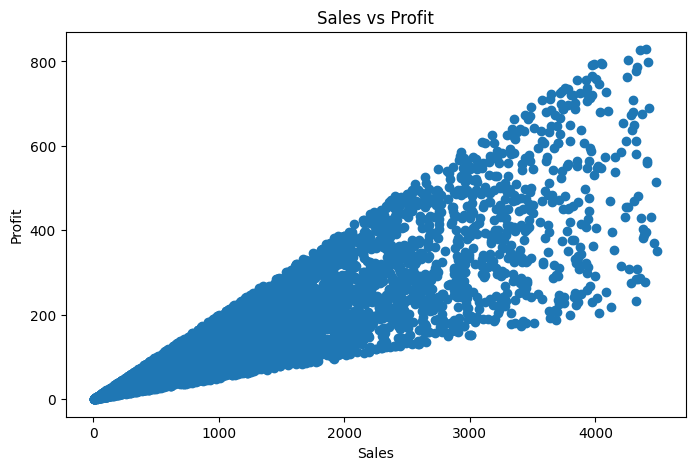

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Visualization 7: Profit Margin Spread (Box Plot)

- This box plot shows how profit margin varies across orders.
- It helps detect low and high profitability orders.

In [17]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [18]:
df[['Profit', 'Sales', 'Profit_Margin']].head()

,Profit,Sales,Profit_Margin
0,87.37,475.66,18.368162
1,171.46,1148.05,14.934890
2,50.21,458.24,10.957140
3,793.50,4055.04,19.568241
4,2.27,14.54,15.612105


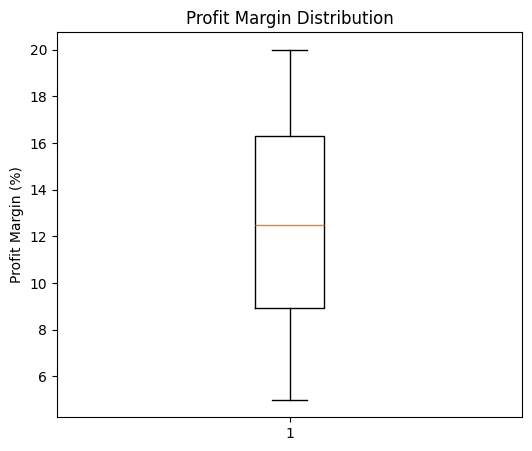

In [19]:
plt.figure(figsize=(6,5))
plt.boxplot(df['Profit_Margin'])
plt.title("Profit Margin Distribution")
plt.ylabel("Profit Margin (%)")
plt.show()

## Visualization 8: Correlation Heatmap

- This heatmap shows how numerical variables are related.
- It helps understand relationships between sales, profit, quantity, etc.

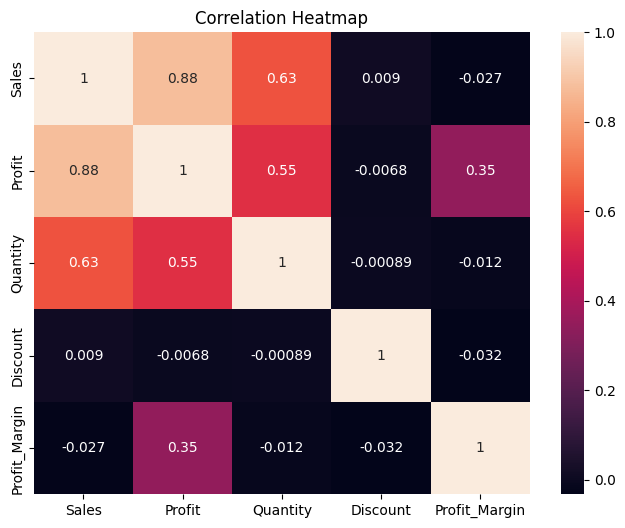

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Profit','Quantity','Discount','Profit_Margin']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Visualization 9: Sales by Payment Method (Bar Chart)

- This bar chart shows total sales by each payment method.
- It helps understand which payment modes customers use most for spending.

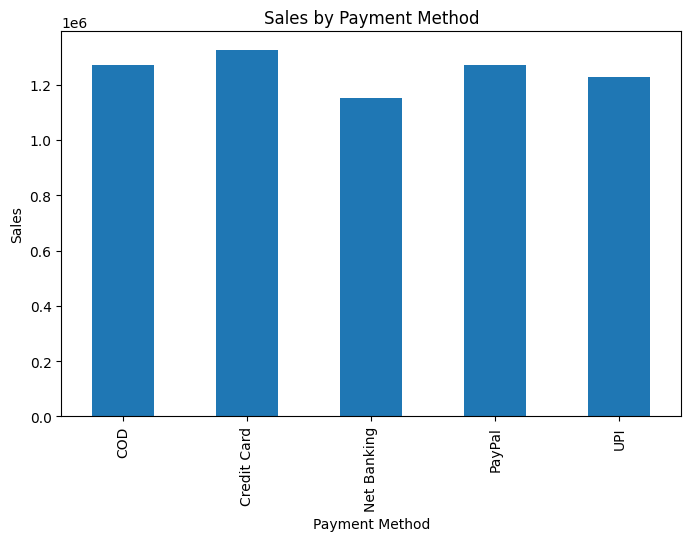

In [21]:
payment_sales = df.groupby('Payment_Method')['Sales'].sum()
plt.figure(figsize=(8,5))
payment_sales.plot(kind='bar')
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")
plt.show()

## Visualization 10: Profit by Customer Segment (Bar Chart)

- This chart shows how profit is distributed across different customer segments.
- It helps identify the most valuable customer groups.

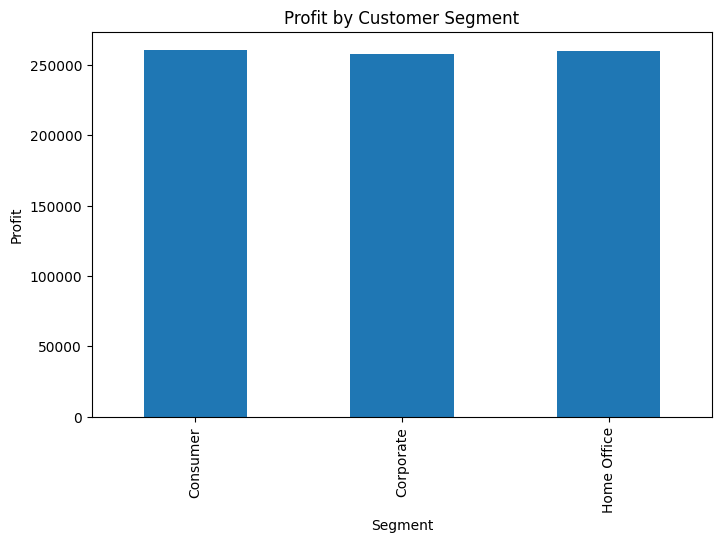

In [22]:
segment_profit = df.groupby('Segment')['Profit'].sum()
plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show()

## Insight Generation and Report

## Key Business Insights

Based on the exploratory data analysis and visualizations, the following insights were obtained from the Superstore Sales dataset:

## 1. Overall Business Performance

- The business generated high total sales and strong profit, indicating a healthy revenue model.

- The average order value is reasonably high, showing that customers typically purchase multiple or higher-priced items.

## 2.  Product Category Performance

- Some product categories generate higher sales than others.

- Categories such as Electronics, Clothing, and Home products contribute significantly to revenue.

- Profit analysis shows that high sales do not always mean high profit, which highlights the importance of profit margin.

## 3. Country-wise Sales

- Countries like USA, Canada, and India are among the top contributors to total sales.

- This suggests these regions have strong customer demand and could be prioritized for marketing and expansion.

## 4. Customer Payment Behavior

- Customers use multiple payment methods such as Credit Card, PayPal, COD, UPI, and Net Banking.

- Digital payment methods have a high usage rate, indicating customer preference for online payments.

## 5. Sales Trend Over Time

- Monthly sales analysis shows that sales vary across months, indicating seasonal trends.

- Some months perform better than others, which can help in planning promotions and inventory.

## 6. Profitability Analysis

- The Profit Margin analysis shows that most orders generate between 8% to 16% profit.

- A few orders have very high or low margins, which may require further investigation.

## 7. Relationship Between Sales and Profit

- The scatter plot confirms a positive relationship between Sales and Profit.

- Higher sales usually lead to higher profit, but profit is also influenced by discounts and pricing.

## 8. Correlation Findings

- Sales and Profit are strongly correlated, meaning revenue growth directly improves profitability.

- Quantity also shows a positive relationship with sales and profit.

- Discounts have very low or negative correlation with profit margin, indicating heavy discounts can reduce profitability.

  

### Business Recommendations

Based on the analysis, the following actions are recommended:

- Focus marketing efforts on high-revenue and high-profit categories such as Electronics, Clothing, and Home products.
- Increase promotions and availability in top-performing countries like USA, Canada, and India.
- Encourage digital payment methods (Credit Card, UPI, PayPal) through offers, as customers prefer them.
- Review discount strategy, as high discounts may reduce profit margin.
- Track monthly sales trends to plan inventory and seasonal promotions.

## Final Conclusion

This analysis reveals that the Superstore has a strong sales and profit structure with clear patterns across product categories, countries, and time periods.
Understanding these trends can help the business:

- Improve pricing and discount strategies

- Focus on high-performing categories

- Target profitable customer segments

- Plan better marketing and inventory strategies

Overall, the dataset provides valuable insights that can support better business decisions and revenue growth.